Load in model and package requirements

In [1]:
import glob
import h5py
import importlib
import IPython.display as ipd
import soxr
import numpy as np
import os
import pandas as pd
import pickle
import soundfile as sf
import src.audio_transforms as at
import src.custom_modules as cm
import src.spatial_attn_lightning as binaural_lightning
importlib.reload(binaural_lightning)
import sys
import torch
import tqdm
import yaml

from pathlib import Path
from pytorch_lightning import Trainer
from scipy import signal
from scipy.io.wavfile import read, write

sys.path.append('../')
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
config = yaml.load(open('/om2/user/rphess/Auditory-Attention/config/binaural_attn/location_task_location_cue.yml', 'r'), Loader=yaml.FullLoader)
config['corpus']['skip_negative_elev'] = False

In [3]:
ckpt_path = '/om2/user/rphess/Auditory-Attention/attn_cue_models/location_task_location_cue/checkpoints/epoch=0-step=4500.ckpt'

In [17]:
!nvidia-smi

Wed Jul  5 14:28:49 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 515.86.01    Driver Version: 515.86.01    CUDA Version: 11.7     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA A100 80G...  On   | 00000000:C4:00.0 Off |                    0 |
| N/A   42C    P0    76W / 300W |   2205MiB / 81920MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [5]:
model = binaural_lightning.BinauralAttentionModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config).cuda()

num_classes={'num_locs': 505}
Model performing location task
cochlea_filt {'sr': 50000, 'env_sr': 10000, 'n_channels': 40, 'low_lim': 40, 'use_pad': True, 'binaural': True, 'rep_on_gpu': True, 'center_crop': True, 'out_dur': 2, 'impulse_len': 0.25, 'env_extraction_type': 'Half-wave Rectification', 'downsampling_type': 'TorchTransformsResample', 'downsampling_kwargs': {'lowpass_filter_width': 64, 'rolloff': 0.9475937167399596, 'resampling_method': 'kaiser_window', 'beta': 14.769656459379492}} coch_p3 {'scale': 1, 'offset': 1e-07, 'clip_value': 5, 'power': 0.3}
center_crop=True
binaural=True
Binaural cochleagram
using FIR cochleagram


Read in spatiliazed sounds and IRs

In [6]:
spatialized_sounds = h5py.File('/om2/user/rphess/Auditory-Attention/first_376.h5', 'r', swmr=True)

In [19]:
target_locs = [(90, 0), (80,0), (70,0), (60,0), (50,0), (40, 0), (30,0), (20,0), (10,0), (0, 0), (350,0), (340,0), (330,0), (320, 0), (310,0), (300,0), (290, 0), (280,0), (270, 0)]
sound = dict()
for loc in target_locs:
    key = f'{loc[0]}_{loc[1]}'
    sound[loc] = spatialized_sounds[key]

In [8]:
print("Loading speaker array room BRIRs")
list_data_dict = []
for elev in [-20, -10, 0, 10, 20, 30, 40]:
    for azim in np.arange(0, 360, 5):
        data_dict = {
            'azim': azim,
            'elev': elev,
            'brir': [],
        }
        for ear in ['l', 'r']:
            basename = f'{elev}elev_{azim}az_2.47x2.60y2.00z_{ear}.wav'
            if elev >= 0:
                fn = os.path.join('/om/user/francl/Room_Simulator_20181115_Rebuild/room_HRIRs/', basename)
            else:
                fn = os.path.join('/om/user/francl/Room_Simulator_20181115_Rebuild/room_HRIRs/neg_elevs/', basename)
            assert os.path.exists(fn)
            brir, sr_src = sf.read(fn)
            sr = 50000
            brir = soxr.resample(brir.astype(np.float32), sr_src, sr)
            data_dict['brir'].append(brir)
        data_dict['sr'] = sr
        data_dict['brir'] = np.stack(data_dict['brir'], axis=-1)
        list_data_dict.append(data_dict)
df_brir = pd.DataFrame(list_data_dict)
df_brir_room = df_brir[np.logical_and.reduce([
    df_brir['azim'] % 10 == 0,
    ~(np.logical_and(df_brir['azim'] > 90, df_brir['azim'] < 270)),
    df_brir['elev'] >= 0,
])].reset_index()
print(f"Loaded speaker array room BRIRs ({len(df_brir_room)})")

Loading speaker array room BRIRs
Loaded speaker array room BRIRs (95)


Functions for generating trials on the fly

In [9]:
def generate_white_noise(length, sr=50000):
    samples = int(length * sr)
    # model is trained with random normal white noise
    return np.random.normal(0, 1, size=samples).astype(np.float32)

In [10]:
def azim_elev_to_label(azim, elev):
    return np.array(((elev / 10) * 72) + (azim / 5) + 1, dtype=np.int64)

In [11]:
def mass_spatialize(words, ir):
    """Uses pytorch to convolve all sounds in words with 2 channel IR given in ir"""
    n_words = words.shape[0]
    words_padded = [torch.nn.functional.pad(word, (ir.shape[0] - 1, 0)) for word in words]
    ir = ir.T.unsqueeze(1)
    words_padded = torch.stack(words_padded)
    spatialized = torch.nn.functional.conv1d(words_padded.view(n_words, 1, -1).cuda(), ir.cuda()).cuda()
    return spatialized

In [12]:
label_dict = dict()
for azim in np.arange(0, 360, 5):
    for elev in np.arange(0, 61, 10):
        label_dict[(azim, elev)] = int(azim_elev_to_label(azim, elev))

In [13]:
class_ix_to_label = {v: k for k, v in label_dict.items()}

In [14]:
audio_transforms = model.audio_transforms

Code to evaluate location model with location cues

In [86]:
# forward is cue, mixture, None
def location_model_accuracy(model, location, sound, df_brir_room, audio_transforms):
    # Get BRIR for the given location in the speaker room
    ir = df_brir_room[(df_brir_room['azim'] == location[0]) & (df_brir_room['elev'] == location[1])]['brir'].values[0]
    # Flip the BRIR for proper convolution
    loc_brir = torch.flip(torch.Tensor(ir), dims=[0])

    # get the index of the proper label for the location
    label = azim_elev_to_label(location[0], location[1])
    # Initialize results list
    correct = []
    # get array of shape (n_words, channels, samples) which is (376, 2, 150000) as of 6/29/2023
    speech_array = sound[location]['signal'][:]
    # iterate through word examples
    for i in tqdm.tqdm(range(speech_array.shape[0])):
        # generate white noise of length 3 seconds
        white_noise = torch.tensor(generate_white_noise(3)).view(1, -1)
        # spatialize the white noise
        cue = np.array(mass_spatialize(white_noise, loc_brir).cpu())
        # cut the white noise to 2.5 seconds
        cue = cue[:, :, 12500:137500]
        # pass through the model's audio transforms
        cue = audio_transforms(cue, None)[0].squeeze(0)

        # get pre-spatilized word
        mixture = speech_array[i]
        # cut to 2.5 seconds
        mixture = mixture[:, 12500:137500]
        # pass through the model's audio transforms
        mixture = audio_transforms(mixture, None)[0]

        # pass transformed audio through model
        out = model.forward(cue.cuda(), mixture.cuda(), None)
        # take the softmax of model logits
        softmax_outputs = torch.nn.functional.softmax(out, dim=-1)
        # get the index of the maximum value
        result = torch.argmax(softmax_outputs, dim=-1)
        # check to see if this index matches the location label and append to results list
        correct.append((result.cpu(), torch.tensor(label)))
    return correct

In [80]:
acc = location_model_accuracy(model, (90, 0), sound, df_brir_room, audio_transforms)

100%|██████████| 376/376 [01:06<00:00,  5.64it/s]


In [82]:
results = []
for result, label in acc:
    for i in range(len(result)):
        r = class_ix_to_label[int(result[i])]
        l = class_ix_to_label[int(label.item())]
        results.append((r, l))

In [72]:
acc = []
for loc in target_locs:
    acc.extend(location_model_accuracy(model, loc, sound, df_brir_room, audio_transforms))

100%|██████████| 376/376 [01:06<00:00,  5.67it/s]


In [21]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
results = []
for result, label in acc:
    for i in range(len(result)):
        r = class_ix_to_label[int(result[i])]
        l = class_ix_to_label[int(label.item())]
        results.append((r, l))

[Text(0, 0, '-90'),
 Text(1, 0, '-80'),
 Text(2, 0, '-70'),
 Text(3, 0, '-60'),
 Text(4, 0, '-50'),
 Text(5, 0, '-40'),
 Text(6, 0, '-30'),
 Text(7, 0, '-20'),
 Text(8, 0, '-10'),
 Text(9, 0, '0'),
 Text(10, 0, '10'),
 Text(11, 0, '20'),
 Text(12, 0, '30'),
 Text(13, 0, '40'),
 Text(14, 0, '50'),
 Text(15, 0, '60'),
 Text(16, 0, '70'),
 Text(17, 0, '80'),
 Text(18, 0, '90')]

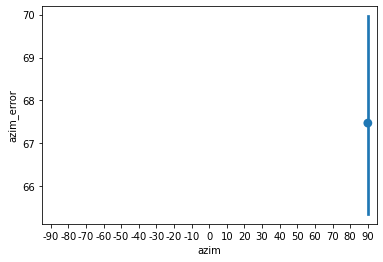

In [83]:
azims = [r[1][0] for r in results]
azim_error = [abs(r[0][0] - r[1][0]) if abs(r[0][0] - r[1][0]) < 180 else 360 - abs(r[0][0] - r[1][0]) for r in results]
azims_df = pd.DataFrame({'azim': azims, 'azim_error': azim_error})
g = sns.pointplot(x='azim', y='azim_error', data=azims_df, order=[270, 280, 290, 300, 310, 320, 330, 340, 350, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
g.set_xticklabels([-90, -80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

[Text(0, 0, '-90'),
 Text(1, 0, '-80'),
 Text(2, 0, '-70'),
 Text(3, 0, '-60'),
 Text(4, 0, '-50'),
 Text(5, 0, '-40'),
 Text(6, 0, '-30'),
 Text(7, 0, '-20'),
 Text(8, 0, '-10'),
 Text(9, 0, '0'),
 Text(10, 0, '10'),
 Text(11, 0, '20'),
 Text(12, 0, '30'),
 Text(13, 0, '40'),
 Text(14, 0, '50'),
 Text(15, 0, '60'),
 Text(16, 0, '70'),
 Text(17, 0, '80'),
 Text(18, 0, '90')]

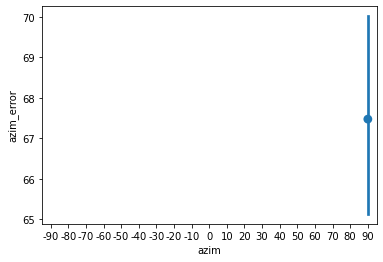

In [85]:
# re-plot with front-back folding
azims = [r[1][0] for r in results]
guesses = [r[0][0] for r in results]
for i in range(len(guesses)):
    if guesses[i] > 90 and guesses[i] < 270:
        if guesses[i] <= 180:
            guesses[i] = 180 - guesses[i]
        else:
            guesses[i] = 360 - (guesses[i] % 180)
azim_error = [abs(guesses[i] - azims[i]) if abs(guesses[i] - azims[i]) < 180 else 360 - abs(guesses[i] - azims[i]) for i in range(len(guesses))]
azims_df = pd.DataFrame({'azim': azims, 'azim_error': azim_error})
g = sns.pointplot(x='azim', y='azim_error', data=azims_df, order=[270, 280, 290, 300, 310, 320, 330, 340, 350, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
g.set_xticklabels([-90, -80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

[Text(0, 0, '-90'),
 Text(1, 0, '-80'),
 Text(2, 0, '-70'),
 Text(3, 0, '-60'),
 Text(4, 0, '-50'),
 Text(5, 0, '-40'),
 Text(6, 0, '-30'),
 Text(7, 0, '-20'),
 Text(8, 0, '-10'),
 Text(9, 0, '0'),
 Text(10, 0, '10'),
 Text(11, 0, '20'),
 Text(12, 0, '30'),
 Text(13, 0, '40'),
 Text(14, 0, '50'),
 Text(15, 0, '60'),
 Text(16, 0, '70'),
 Text(17, 0, '80'),
 Text(18, 0, '90')]

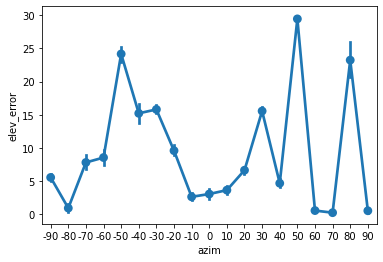

In [76]:
azims = [r[1][0] for r in results]
elev_error = [abs(r[0][1] - r[1][1]) if abs(r[0][1] - r[1][1]) < 180 else 360 - abs(r[0][1] - r [1][1]) for r in results]
elevs_df = pd.DataFrame({'azim': azims, 'elev_error': elev_error})
g = sns.pointplot(x='azim', y='elev_error', data=elevs_df, order=[270, 280, 290, 300, 310, 320, 330, 340, 350, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
g.set_xticklabels([-90, -80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

Tests with validation set

In [26]:
val_path = '/om/scratch/Wed/imgriff/datasets/spatial_audio_pipeline/assets/dataset_binaural_attn/v02/validation/'

In [27]:
val_sets = glob.glob(val_path + '*')

In [28]:
eg_val = h5py.File(val_sets[0], 'r', swmr=True) 

In [29]:
model.config['num_workers'] = 0
model.config['hparas']['batch_size'] = 4

In [30]:
val_loader = model.val_dataloader()

49 files in val concat dataset


In [33]:
def val_set_accuracy(model):
    correct = []
    i = 0
    for cue, c_m_i, scene, label in tqdm.tqdm(val_loader):
        out = model(cue.cuda(), scene.cuda(), c_m_i.cuda())
        softmax_outputs = torch.nn.functional.softmax(out, dim=-1)
        result = torch.argmax(softmax_outputs, dim=-1)
        correct.append((result.cpu(), label.cpu()))
        i+=1
        if i == 500:
            return correct
    return correct

In [34]:
acc = val_set_accuracy(model)

  1%|▏         | 499/37419 [02:28<3:03:38,  3.35it/s]


In [35]:
results = []
for result, label in acc:
    for i in range(len(result)):
        try:
            r = class_ix_to_label[int(result[i])]
            l = class_ix_to_label[int(label[i])]
        except:
            continue
        results.append((r, l))

<AxesSubplot:xlabel='azim', ylabel='azim_error'>

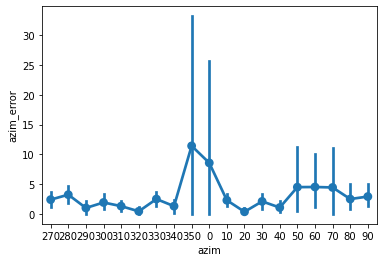

In [36]:
azims = [r[1][0] for r in results]
azim_error = [abs(r[0][0] - r[1][0]) if abs(r[0][0] - r[1][0]) < 180 else 360 - abs(r[0][0] - r[1][0]) for r in results]
azims_df = pd.DataFrame({'azim': azims, 'azim_error': azim_error})
wanted_azims = [270, 280, 290, 300, 310, 320, 330, 340, 350, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
to_plot = azims_df[azims_df['azim'].isin(wanted_azims)]
sns.pointplot(x='azim', y='azim_error', data=to_plot, order=[270, 280, 290, 300, 310, 320, 330, 340, 350, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

(0.0, 14.0)

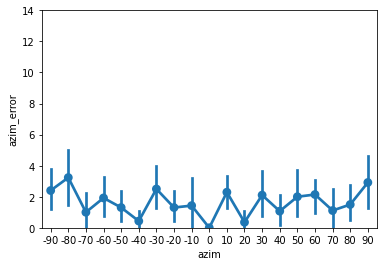

In [44]:
azims = [r[1][0] for r in results]
guesses = [r[0][0] for r in results]
for i in range(len(guesses)):
    if guesses[i] > 90 and guesses[i] < 270:
        if guesses[i] <= 180:
            guesses[i] = 180 - guesses[i]
        else:
            guesses[i] = 360 - (guesses[i] % 180)
azim_error = [abs(guesses[i] - azims[i]) if abs(guesses[i] - azims[i]) < 180 else 360 - abs(guesses[i] - azims[i]) for i in range(len(guesses))]
azims_df = pd.DataFrame({'azim': azims, 'azim_error': azim_error})
wanted_azims = [270, 280, 290, 300, 310, 320, 330, 340, 350, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
to_plot = azims_df[azims_df['azim'].isin(wanted_azims)]
g = sns.pointplot(x='azim', y='azim_error', data=to_plot, order=[270, 280, 290, 300, 310, 320, 330, 340, 350, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
g.set_xticklabels([-90, -80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
plt.ylim(0,14)

(0.0, 14.0)

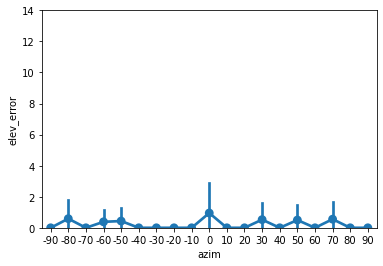

In [68]:
elevs = [r[1][1] for r in results]
elev_error = [abs(r[0][1] - r[1][1]) if abs(r[0][1] - r[1][1]) < 180 else 360 - abs(r[0][1] - r [1][1]) for r in results]
elevs_df = pd.DataFrame({'azim': azims, 'elev_error': elev_error})
to_plot =elevs_df[elevs_df['azim'].isin(wanted_azims)]
g = sns.pointplot(x='azim', y='elev_error', data=to_plot, order=[270, 280, 290, 300, 310, 320, 330, 340, 350, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
g.set_xticklabels([-90, -80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
plt.ylim(0,14)

Validate with room from validations set

In [45]:
h5_file = '/om2/user/rphess/Auditory-Attention/Room_HRIRs_50kHz.h5'
hrirs = h5py.File(h5_file, 'r', swmr=True)

In [57]:
speaker_dir = '/om2/user/imgriff/datasets/commonvoice_9_en/3000ms/stimSR_50000/cv_9_en/subsets/'
speaker_paths = glob.glob(speaker_dir + 'model_and_participant_test_set/*')
speaker_h5 = h5py.File(speaker_paths[0], 'r', swmr=True)

In [58]:
rand_room = np.random.choice(list(hrirs.keys()))
room = hrirs[rand_room]
listener_locs = list(room.keys())
listener = room[listener_locs[0]]
impulse_response = listener['irs']

In [60]:
ixs_0_elev = [ix for ix, elev in enumerate(listener['elevation']) if elev == 0]
ixs = []
for ix in ixs_0_elev:
    if listener['azimuth'][ix] in (270, 280, 290, 300, 310, 320, 330, 340, 350, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90):
        ixs.append(ix)

<HDF5 dataset "signal": shape (598, 150000), type "<f4">